## Imports

In [1]:
from collections import Counter, defaultdict
from pathlib import Path
import sys
import random
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.config import get_project_root, load_config, get_path
from src.utils.data import (
    get_train_images_dir,
    get_test_images_dir,
    get_annotations_path,
    load_annotations,
    remove_duplicate_annotations
)
from src.processing.masks import build_masks
from src.splitting.split import split_masks
from src.datasets.segmentation import SegmentationDataset
from src.training.dataloaders import create_dataloaders
from src.models.unet import UNet
from src.training.losses import BCEDiceLoss
from src.training.trainer import train_model

PROJECT_ROOT = get_project_root()
CONFIG = load_config()

print(f"Project root: {PROJECT_ROOT}")

Project root: C:\Users\Darío\Desktop\KAGGLE\kaggle_solar_filament_segmentation


## Load data

In [15]:
RAW_DATA_DIR = PROJECT_ROOT / CONFIG["paths"]["raw_data_dir"]

TRAIN_IMAGES_DIR = get_train_images_dir(RAW_DATA_DIR)
TEST_IMAGES_DIR = get_test_images_dir(RAW_DATA_DIR)
ANNOTATIONS_PATH = get_annotations_path(RAW_DATA_DIR)

annotations = load_annotations(ANNOTATIONS_PATH)

In [16]:
annotations_clean = remove_duplicate_annotations(annotations)

print(f"Images: {len(annotations_clean['images']):,}")
print(f"Annotations: {len(annotations_clean['annotations']):,}")

Images: 707
Annotations: 5,209


## Build masks

In [17]:
final_masks = build_masks(annotations_clean)

In [18]:
file_name = next(iter(final_masks))

print(file_name)
print(len(final_masks[file_name]))
print(final_masks[file_name][0].shape)

20140609195854Bh.jpeg
12
(2048, 2048)


In [ ]:
file_name = random.choice(list(final_masks.keys()))

mask = final_masks[file_name][0]

print(mask)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


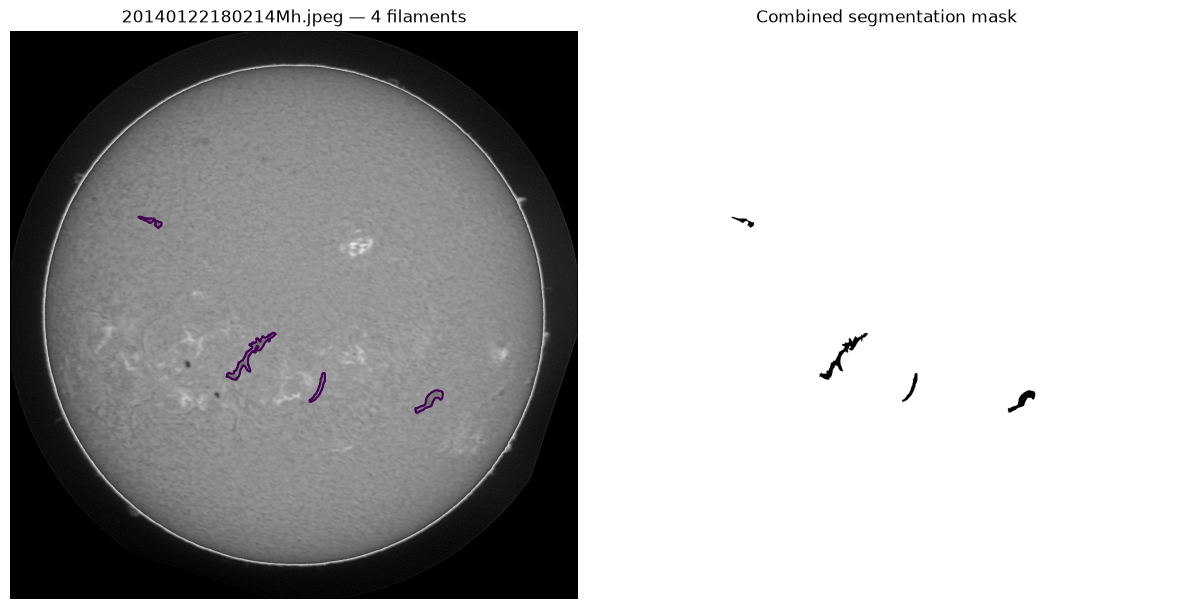

In [20]:
# Seleccionar una imagen aleatoria
file_name = random.choice(list(final_masks.keys()))

# Cargar imagen
image = np.array(
    Image.open(TRAIN_IMAGES_DIR / file_name)
)

# Obtener máscaras de la imagen
masks = final_masks[file_name]

# Combinar todas las máscaras
combined_mask = np.any(
    np.stack(masks),
    axis=0
)


# Visualización
fig, axes = plt.subplots(1, 2, figsize=(12, 6))

# Imagen original + contornos
axes[0].imshow(image, cmap="gray")

for mask in masks:
    axes[0].contour(
        mask,
        levels=[0.5],
        linewidths=1.5,
    )

axes[0].set_title(
    f"{file_name} — {len(masks)} filaments"
)
axes[0].axis("off")


# Máscara binaria
axes[1].imshow(
    combined_mask,
    cmap="gray_r",
    vmin=0,
    vmax=1,
)

axes[1].set_title("Combined segmentation mask")
axes[1].axis("off")


plt.tight_layout()
plt.show()

In [21]:
foreground_ratios = []

for file_name, masks in final_masks.items():

    # Combinar todos los filamentos de la imagen
    combined_mask = np.any(
        np.stack(masks),
        axis=0,
    )

    # Porcentaje de píxeles pertenecientes a filamentos
    foreground_ratio = combined_mask.mean()

    foreground_ratios.append({
        "file_name": file_name,
        "foreground_pixels": int(combined_mask.sum()),
        "foreground_ratio": foreground_ratio,
        "foreground_percentage": foreground_ratio * 100,
    })

foreground_df = pd.DataFrame(foreground_ratios)

foreground_df.head()

,file_name,foreground_pixels,foreground_ratio,foreground_percentage
0,20140609195854Bh.jpeg,18170,0.004332,0.433207
1,20111116063134Lh.jpeg,31659,0.007548,0.754809
2,20130725122934Ch.jpeg,26412,0.006297,0.629711
3,20141027025054Uh.jpeg,41715,0.009946,0.994563
4,20160714235434Lh.jpeg,20300,0.004840,0.483990


In [22]:
foreground_df["foreground_percentage"].describe()

count    707.000000
mean       0.381328
std        0.290472
min        0.010014
25%        0.143421
50%        0.333905
75%        0.550008
max        1.710892
Name: foreground_percentage, dtype: float64

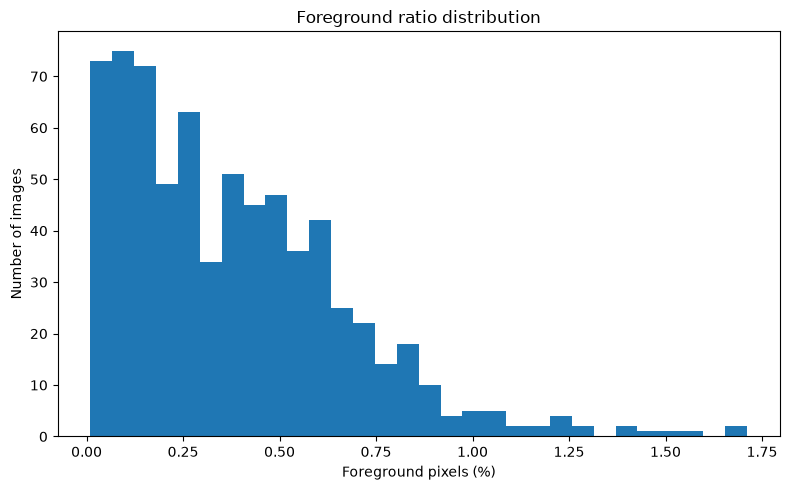

In [23]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(
    foreground_df["foreground_percentage"],
    bins=30,
)

ax.set_xlabel("Foreground pixels (%)")
ax.set_ylabel("Number of images")
ax.set_title("Foreground ratio distribution")

plt.tight_layout()
plt.show()

### Foreground ratio

The segmented filaments occupy a relatively small fraction of each image, with a mean foreground ratio of **0.38%** and a median of **0.33%**. However, the variability across images is considerable, ranging from **0.01% to 1.71%**.

This confirms a strong **class imbalance** between filament and background pixels. Therefore, using a standard binary cross-entropy loss alone may cause the model to favor the background class.

## Splitting

In [24]:
train_masks, val_masks, test_masks = split_masks(
    final_masks,
    train_size=0.8,
    val_size=0.1,
    test_size=0.1,
    random_state=42,
)

print(f"Train:      {len(train_masks):,} images")
print(f"Validation: {len(val_masks):,} images")
print(f"Test:       {len(test_masks):,} images")
print(f"Total:      {len(final_masks):,} images")

Train:      565 images
Validation: 71 images
Test:       71 images
Total:      707 images


## Pytorch datasets & dataloaders

In [28]:
train_dataset = SegmentationDataset(
    masks=train_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

val_dataset = SegmentationDataset(
    masks=val_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

test_dataset = SegmentationDataset(
    masks=test_masks,
    images_dir=TRAIN_IMAGES_DIR,
)

train_loader, val_loader, test_loader = create_dataloaders(
    train_dataset=train_dataset,
    val_dataset=val_dataset,
    test_dataset=test_dataset,
    batch_size=1,
    num_workers=0,
    pin_memory=True,
)

images, masks_batch = next(iter(train_loader))

print(f"Train batches: {len(train_loader)}")
print(f"Image batch shape: {images.shape}")
print(f"Mask batch shape:  {masks_batch.shape}")

Train batches: 565
Image batch shape: torch.Size([1, 1, 2048, 2048])
Mask batch shape:  torch.Size([1, 1, 2048, 2048])


## Building the U-Net

In [34]:
model = UNet(
    in_channels=1,
    out_channels=1,
    base_channels=16,
)

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print(f"Device: {device}")

if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4070


## Loading our loss function

In [31]:
loss_fn = BCEDiceLoss(
    bce_weight=0.5,
    dice_weight=0.5,
)

## Training

In [ ]:
models_dir = get_path(CONFIG["paths"]["models_dir"])

history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    loss_fn=loss_fn,
    epochs=50,
    learning_rate=1e-3,
    weight_decay=1e-4,
    patience=7,
    scheduler_patience=3,
    scheduler_factor=0.5,
    threshold=0.5,
    device=device,
    use_amp=True,
    checkpoint_path=models_dir / "unet_checkpoint.pth",
)

Epoch 01/50 | Train Loss: 0.5401 | Train Dice: 0.2483 | Train IoU: 0.1626 | Val Loss: 0.4240 | Val Dice: 0.2620 | Val IoU: 0.1582 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.2620)
Epoch 02/50 | Train Loss: 0.2885 | Train Dice: 0.4824 | Train IoU: 0.3322 | Val Loss: 0.4936 | Val Dice: 0.0471 | Val IoU: 0.0257 | LR: 1.00e-03
Epoch 03/50 | Train Loss: 0.2569 | Train Dice: 0.5155 | Train IoU: 0.3617 | Val Loss: 0.3142 | Val Dice: 0.3994 | Val IoU: 0.2684 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.3994)
Epoch 04/50 | Train Loss: 0.2411 | Train Dice: 0.5447 | Train IoU: 0.3868 | Val Loss: 0.3069 | Val Dice: 0.4141 | Val IoU: 0.2816 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.4141)
Epoch 05/50 | Train Loss: 0.2342 | Train Dice: 0.5561 | Train IoU: 0.3972 | Val Loss: 0.2318 | Val Dice: 0.5587 | Val IoU: 0.4053 | LR: 1.00e-03
  -> Best model saved (Val Dice: 0.5587)
Epoch 06/50 | Train Loss: 0.2288 | Train Dice: 0.5660 | Train IoU: 0.4066 | Val Loss: 0.2314 | Val Dice: 0.5609